In [1]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
import seaborn as sns
import scipy.stats as stats

## config font size and family

In [2]:
plt.rcParams.update({
    'font.size': 20,  
    'font.family': 'Arial',
    'axes.labelsize': 24,  
    'axes.labelpad': 10
})

bbox_style = dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')

## define some functions for visualization

In [3]:
def fit_line(x, y):
    """Fit a line to the data and return slope and intercept."""
    m, c = np.polyfit(x, y, 1)
    return m, c

def calculate_rmse(y_true, y_pred):
    """Calculate Root Mean Square Error."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calculate_r2(y_true, y_pred):
    """Calculate R-squared."""
    import sklearn.metrics as metrics
    return metrics.r2_score(y_true, y_pred)

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculate_smape(y_true, y_pred):
    """Calculate Symmetric Mean Absolute Percentage Error."""
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# node-level visualization

In [4]:
sampled_nodes_full = pd.read_csv('./SF_sampled_nodes.csv')

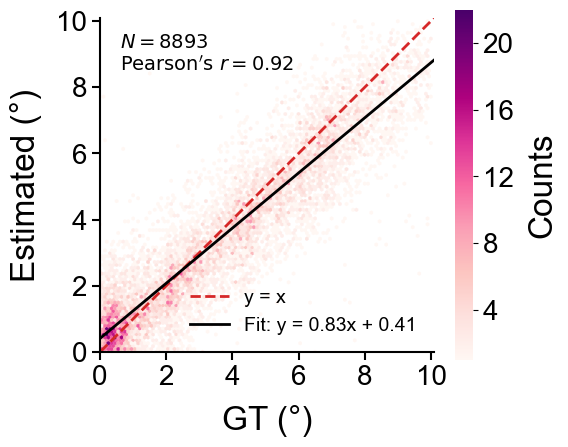

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

x = sampled_nodes_full['GT'].values
y = sampled_nodes_full['post_huber'].values
N = len(x)

h = ax.hexbin(
    x, y,
    gridsize=100,
    cmap='RdPu',
    mincnt=0.5,
    linewidths=0.2,
    reduce_C_function=np.sum
)
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=6))
cb.outline.set_visible(False)

ax.plot([0, 18], [0, 18], color='#d62728', linestyle='--', linewidth=2, label='y = x')

m, c = fit_line(x, y)
ax.plot([0, 18], [c, m * 18 + c], color="#000000", linestyle='-', linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

person_r = stats.pearsonr(y, x)[0]
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={person_r:.2f}$"
ax.text(0.6, 0.85*10, metrics_text, color='black',fontsize=14)

ax.set_xlabel('GT (°)')
ax.set_ylabel('Estimated (°)')
ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks(np.arange(0, 11, 2))
ax.set_xlim(0, 10.1)
ax.set_ylim(0, 10.1)

# 关键：强制 1:1 比例
ax.set_aspect('equal', adjustable='box')

ax.legend(frameon=False, loc='lower right', fontsize=14)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

plt.tight_layout()
plt.show()

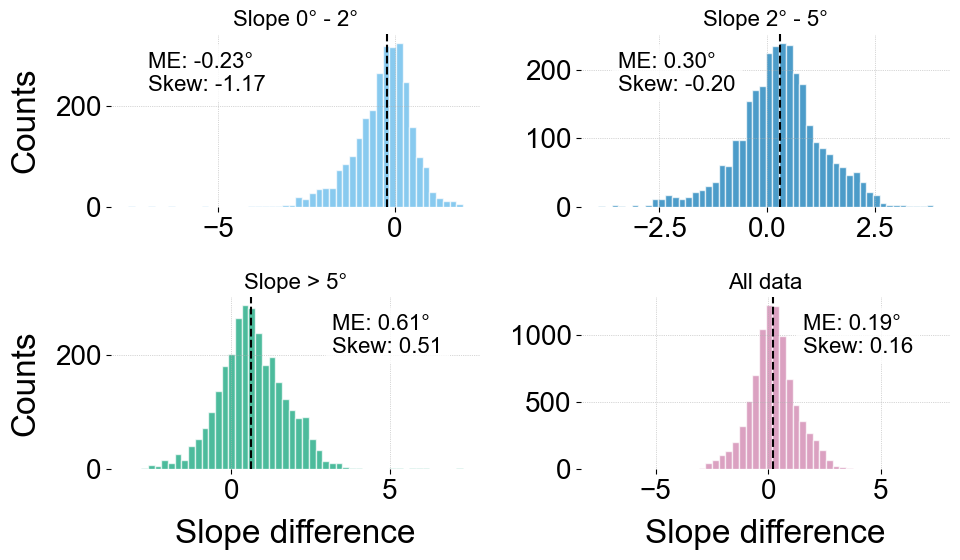

In [6]:
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 2), (2, 5), (5, 10)]
titles = ['Slope 0° - 2°', 'Slope 2° - 5°', 'Slope > 5°']

for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = sampled_nodes_full[(sampled_nodes_full['GT'] >= slope_min) & (sampled_nodes_full['GT'] < slope_max)]

    ax.hist(data_subset['slope_diff_huber'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    
    # Calculate metrics
    median_val = data_subset['slope_diff_huber'].median()
    skewness = data_subset['slope_diff_huber'].skew()
    
    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}°\nSkew: {skewness:.2f}'
    if median_val>0 and skewness>0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)
    else:
        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

# All data in axs[1,1]
all_data = sampled_nodes_full['slope_diff_huber']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)


# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}°\nSkew: {skewness_all:.2f}'

if median_all>0 and skewness_all>0:
    axs[1, 1].text(0.6, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
               fontsize=16)
else:
    axs[1, 1].text(0.1, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Slope difference')
axs[1, 1].set_xlabel('Slope difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')
    #delete the y grid lines

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
from scipy import stats

# calculate the performance metrics among different groups
rmse, mae, mape, skewness, kurtosis, N, r_squared, r, median_relative_error, acceptable_bias_percentage, smape = {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}
acceptable_bias_ranges = [(0, 0.25), (0, 0.5), (0, 0.75) , (0, 1)]
# Define slope ranges and corresponding labels
slope_ranges = [(0, 2), (2, 5), (5, 10)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]

# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels

for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = sampled_nodes_full['GT'].notna()
    else:
        mask = ((sampled_nodes_full['GT'] >= slope_min) & 
                (sampled_nodes_full['GT'] < slope_max))

    subset = sampled_nodes_full[mask]
    # Count the number of samples in this range
    N[label] = sampled_nodes_full[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT'].values
    y_pred = subset['post_huber'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)
    median_relative_error[label] = np.median(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    mape[label] = np.mean(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    smape[label] = calculate_smape(y_true, y_pred)


    # calculate the the acceptable bias percentage
    for bias_min, bias_max in acceptable_bias_ranges:
        bias_label = f"{bias_min} - {bias_max}°"
        bias_mask = (np.abs(y_true - y_pred) >= bias_min) & (np.abs(y_true - y_pred) < bias_max)
        count_in_range = np.sum(bias_mask)
        percentage_in_range = (count_in_range / len(y_true)) * 100
        acceptable_bias_percentage.setdefault(label, {})[bias_label] = percentage_in_range
    # R-squared and Pearson correlation
    r_squared[label] = calculate_r2(y_true, y_pred)
    r[label], _ = stats.pearsonr(y_true, y_pred)
    # Skewness and kurtosis of residuals
    residuals = y_true - y_pred
    skewness[label] = stats.skew(residuals)
    kurtosis[label] = stats.kurtosis(residuals)

# Display results
metrics_df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'sMAPE (%)': smape,
    'N': N,
})

print("Performance Metrics by Slope Range:")
print(metrics_df.round(3))



Performance Metrics by Slope Range:
          RMSE    MAE  sMAPE (%)     N
All      1.093  0.814     38.632  8893
0 - 2°   0.910  0.651     74.297  2832
2 - 5°   1.013  0.777     27.701  3017
5 - 10°  1.304  1.001     16.285  3044


# edge-level slope visualization

In [8]:
sampled_edges_full = pd.read_csv('./SF_sampled_edges_full.csv')

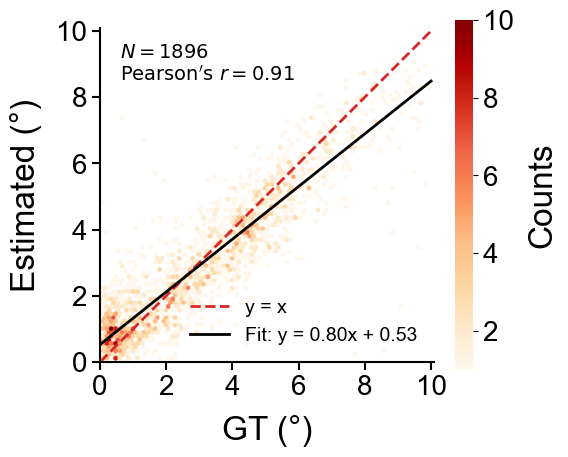

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

x = sampled_edges_full['GT'].values
y = sampled_edges_full['post_huber'].values
N = len(x)

# 2D histogram as density
h = ax.hexbin(
    x, y,
    gridsize=75,
    cmap='OrRd',
    mincnt=0.5,
    linewidths=0.2,
    reduce_C_function=np.sum
)
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')
# ensure ticks formatted nicely (optional), and reduce the number of ticks
# cb.ax.set_yticklabels([f"{int(v)}" for v in cb.get_ticks()])

# only select the ticks that are integers and no decimals
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))

# delete the box of the colorbar
cb.outline.set_visible(False)



# Diagonal reference line
ax.plot([0, 10], [0, 10],
        color='#d62728',
        linestyle='--',
        linewidth=2,
        label='y = x')

# Fitted regression line
m, c = fit_line(x,
                y)

               
ax.plot([0, 10],
        [c, m * 10 + c],
        color="#000000",
        linestyle='-',
        linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

# Metrics annotation
person_r = stats.pearsonr(y, x)[0]
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={person_r:.2f}$"
ax.text(0.6, 0.85*10, metrics_text, color='black',fontsize=14)
    
ax.set_xlabel('GT (°)')
ax.set_ylabel('Estimated (°)')
ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks(np.arange(0, 11, 2))
ax.set_xlim(0, 10.1)
ax.set_ylim(0, 10.1)

ax.legend(frameon=False, loc='lower right', fontsize=14)


ax.set_aspect('equal', adjustable='box')
# delete the top and right spines
ax.spines['top'].set_visible(False)     
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)  
ax.spines['bottom'].set_linewidth(1.5) 

# ticks length
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

plt.tight_layout()
plt.show()

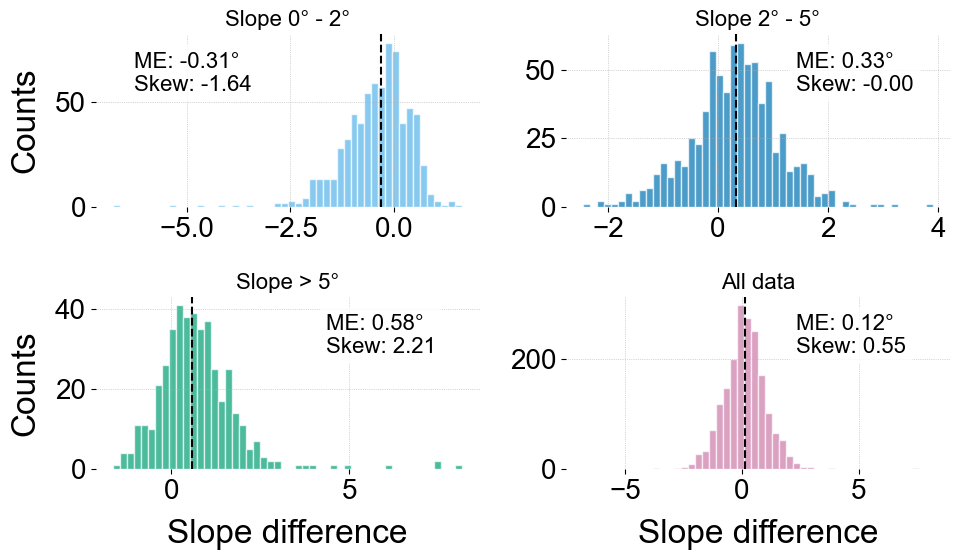

In [10]:
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 2), (2, 5), (5, 10)]
titles = ['Slope 0° - 2°', 'Slope 2° - 5°', 'Slope > 5°']
box_style = dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')
for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = sampled_edges_full[(sampled_edges_full['GT'] >= slope_min) & (sampled_edges_full['GT'] < slope_max)]

    ax.hist(data_subset['slope_diff_huber'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    
    # Calculate metrics
    median_val = data_subset['slope_diff_huber'].median()
    skewness_val = data_subset['slope_diff_huber'].skew()

    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}°\nSkew: {skewness_val:.2f}'

    if median_val>0 and skewness_val>0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)
    elif median_val>0 and skewness_val<0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)
    else:
        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

# All data in axs[1,1]
all_data = sampled_edges_full['slope_diff_huber']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)

# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}°\nSkew: {skewness_all:.2f}'
if median_all>0 and skewness_all>0:
        axs[1, 1].text(0.6, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

else:
        axs[1, 1].text(0.1, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Slope difference')
axs[1, 1].set_xlabel('Slope difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')
    #delete the y grid lines

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
# print the rmse, mae, median_relative_error, Pearson_r for the sampled_edges_full in each slope range
from scipy import stats

# calculate the performance metrics among different groups
rmse, mae, mape, skewness, kurtosis, N, r_squared, r, median_relative_error, acceptable_bias_percentage, smape = {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}
acceptable_bias_ranges = [(0, 0.25), (0, 0.5), (0, 0.75) , (0, 1)]
# Define slope ranges and corresponding labels
slope_ranges = [(0, 2), (2, 5), (5, 10)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]

# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels

for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = sampled_edges_full['GT'].notna()
    else:
        mask = ((sampled_edges_full['GT'] >= slope_min) & 
                (sampled_edges_full['GT'] < slope_max))

    subset = sampled_edges_full[mask]
    # Count the number of samples in this range
    N[label] = sampled_edges_full[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT'].values
    y_pred = subset['post_huber'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)
    median_relative_error[label] = np.median(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    mape[label] = np.mean(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    smape[label] = calculate_smape(y_true, y_pred)

    # calculate the the acceptable bias percentage
    for bias_min, bias_max in acceptable_bias_ranges:
        bias_label = f"{bias_min} - {bias_max}°"
        bias_mask = (np.abs(y_true - y_pred) >= bias_min) & (np.abs(y_true - y_pred) < bias_max)
        count_in_range = np.sum(bias_mask)
        percentage_in_range = (count_in_range / len(y_true)) * 100
        acceptable_bias_percentage.setdefault(label, {})[bias_label] = percentage_in_range
    # R-squared and Pearson correlation
    r_squared[label] = calculate_r2(y_true, y_pred)
    r[label], _ = stats.pearsonr(y_true, y_pred)
    # Skewness and kurtosis of residuals
    residuals = y_true - y_pred
    skewness[label] = stats.skew(residuals)
    kurtosis[label] = stats.kurtosis(residuals)

# Display results
metrics_df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'sMAPE (%)': smape,
    'N': N,
})

print("Performance Metrics by Slope Range:")
print(metrics_df.round(3))

Performance Metrics by Slope Range:
          RMSE    MAE  sMAPE (%)     N
All      1.008  0.724     38.491  1896
0 - 2°   0.937  0.664     69.269   702
2 - 5°   0.848  0.663     22.946   761
5 - 10°  1.328  0.927     15.913   433


# edge-level relief visualization

In [11]:
sampled_edges_full_relief = pd.read_csv('./SF_sampled_edges_full_relief.csv')

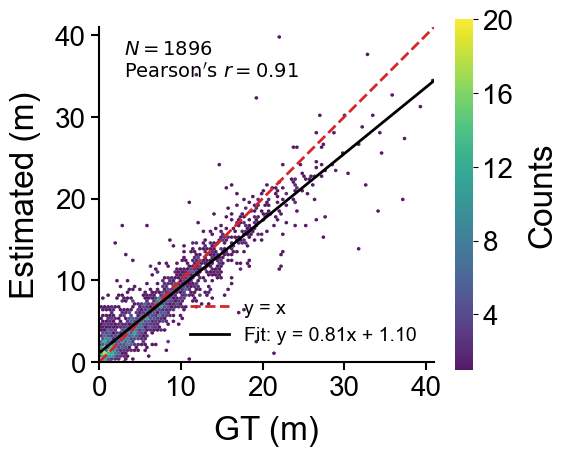

In [12]:
## scatter plot
fig, ax = plt.subplots(figsize=(6, 6))

x = sampled_edges_full_relief['GT_relief'].values
y = sampled_edges_full_relief['post_huber_relief'].values
N = len(x)

# 2D histogram as density
h = ax.hexbin(
    x, y,
    gridsize=150,
    cmap='viridis',   # 换成 perceptually-uniform 色带
    mincnt=1,
    linewidths=0,
    alpha=0.9,
)
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')


# only select the ticks that are integers and no decimals
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=6))


# delete the box of the colorbar
cb.outline.set_visible(False)

# Diagonal reference line
ax.plot([0, 50], [0, 50],
        color='#d62728',
        linestyle='--',
        linewidth=2,
        label='y = x')

# Fitted regression line
m, c = fit_line(x,
                y)
ax.plot([0, 50],
        [c, m * 50 + c],
        color="#000000",
        linestyle='-',
        linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

# Metrics annotation
person_r = stats.pearsonr(y, x)[0]
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={person_r:.2f}$"
ax.text(0.6*5, 0.85*41, metrics_text, color='black', fontsize=14)

ax.set_xlabel('GT (m)')
ax.set_ylabel('Estimated (m)')
ax.set_xticks(np.arange(0, 41, 10))
ax.set_yticks(np.arange(0, 41, 10))
ax.set_xlim(0, 41)
ax.set_ylim(0, 41)

ax.legend(frameon=False, loc='lower right', fontsize=14)

# delete the xgrid
# ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
# delete the top and right spines
ax.spines['top'].set_visible(False)     
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)  # 设置左边框线宽
ax.spines['bottom'].set_linewidth(1.5)  # 设置下边框线宽

# ticks length
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)


plt.tight_layout()
plt.show()

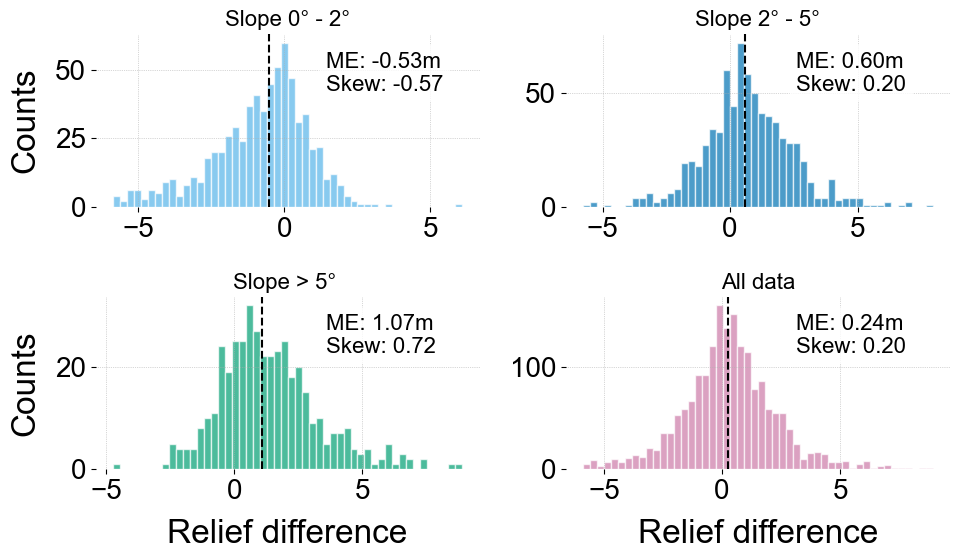

In [13]:
sampled_edges_full_relief['relief_diff_huber'] = sampled_edges_full_relief['GT_relief'] - sampled_edges_full_relief['post_huber_relief']
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 2), (2, 5), (5, 10)]
titles = ['Slope 0° - 2°', 'Slope 2° - 5°', 'Slope > 5° ']
box_style = dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')

# select the 0.01 to 0.99 quantile to plot the histogram
quantile_01 = sampled_edges_full_relief['relief_diff_huber'].quantile(0.01)
quantile_99 = sampled_edges_full_relief['relief_diff_huber'].quantile(0.99)
sampled_edges_full_relief_filtered = sampled_edges_full_relief[(sampled_edges_full_relief['relief_diff_huber'] >= quantile_01) & (sampled_edges_full_relief['relief_diff_huber'] <= quantile_99)]

for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = sampled_edges_full_relief_filtered[(sampled_edges_full_relief_filtered['GT'] >= slope_min) & (sampled_edges_full_relief_filtered['GT'] < slope_max)]

    ax.hist(data_subset['relief_diff_huber'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    # ax.set_xlabel('Slope difference (deg)')
    # ax.set_ylabel('Frequency')
    
    # Calculate metrics
    median_val = data_subset['relief_diff_huber'].median()
    skewness_val = data_subset['relief_diff_huber'].skew()

    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}m\nSkew: {skewness_val:.2f}'
    if median_val>0 and skewness_val>0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left', bbox=box_style,
            fontsize=16)
    elif median_val<0 and skewness_val<0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left', bbox=box_style,
            fontsize=16)
    else:
        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=box_style,
                fontsize=16)

# All data in axs[1,1]
all_data = sampled_edges_full_relief_filtered['relief_diff_huber']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)
# axs[1, 1].set_xlabel('Slope difference (deg)')
# axs[1, 1].set_ylabel('Frequency')

# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}m\nSkew: {skewness_all:.2f}'
if median_all> 0 and skewness_all>0:
    axs[1, 1].text(0.6, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left', bbox=box_style,
               fontsize=16)
else:
    axs[1, 1].text(0.1, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=box_style,
                fontsize=16)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Relief difference')
axs[1, 1].set_xlabel('Relief difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')
    #delete the y grid lines

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()


In [18]:
# print the rmse, mae, median_relative_error, Pearson_r for the sampled_edges_full in each slope range
from scipy import stats

# calculate the performance metrics among different groups
rmse, mae, mape, skewness, kurtosis, N, r_squared, r, median_relative_error, acceptable_bias_percentage, smape = {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}
acceptable_bias_ranges = [(0, 1), (0, 2), (0, 3) , (0, 5)]
# Define slope ranges and corresponding labels
slope_ranges = [(0, 2), (2, 5), (5, 10)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]

# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels

for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = sampled_edges_full['GT'].notna()
    else:
        mask = ((sampled_edges_full['GT'] >= slope_min) & 
                (sampled_edges_full['GT'] < slope_max))

    subset = sampled_edges_full_relief[mask]
    # Count the number of samples in this range
    N[label] = sampled_edges_full[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT_relief'].values
    y_pred = subset['post_huber_relief'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)
    median_relative_error[label] = np.median(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    mape[label] = np.mean(np.abs((y_true - y_pred) / (y_true + 0.1)) * 100)
    smape[label] = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 0.1)) * 100

    # calculate the the acceptable bias percentage
    for bias_min, bias_max in acceptable_bias_ranges:
        bias_label = f"{bias_min} - {bias_max}m"
        bias_mask = (np.abs(y_true - y_pred) >= bias_min) & (np.abs(y_true - y_pred) < bias_max)
        count_in_range = np.sum(bias_mask)
        percentage_in_range = (count_in_range / len(y_true)) * 100
        acceptable_bias_percentage.setdefault(label, {})[bias_label] = percentage_in_range
    # R-squared and Pearson correlation
    r_squared[label] = calculate_r2(y_true, y_pred)
    r[label], _ = stats.pearsonr(y_true, y_pred)
    # Skewness and kurtosis of residuals
    residuals = y_true - y_pred
    skewness[label] = stats.skew(residuals)
    kurtosis[label] = stats.kurtosis(residuals)

# Display results
metrics_df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'sMAPE (%)': smape,
    'N': N,
})

print("Performance Metrics by Slope Range:")
print(metrics_df.round(3))



Performance Metrics by Slope Range:
          RMSE    MAE  sMAPE (%)     N
All      2.859  1.702     37.358  1896
0 - 2°   3.157  1.632     66.410   702
2 - 5°   2.279  1.534     22.741   761
5 - 10°  3.242  2.110     15.945   433
